In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:/Users/ACER/Downloads/Project9_smart-city-traffic-patterns (1)/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns/smart-city-traffic-patterns/TRAINING_TRAFFIC.csv")
df.head(30)

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
5,2015-11-01 05:00:00,1,6,20151101051
6,2015-11-01 06:00:00,1,9,20151101061
7,2015-11-01 07:00:00,1,8,20151101071
8,2015-11-01 08:00:00,1,11,20151101081
9,2015-11-01 09:00:00,1,12,20151101091


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [4]:
df.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [5]:
df.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['DateTime']=pd.to_datetime(df['DateTime'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  48120 non-null  datetime64[ns]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.5 MB


In [9]:
df['DateTime'].min()

Timestamp('2015-11-01 00:00:00')

In [10]:
df['DateTime'].max()

Timestamp('2017-06-30 23:00:00')

In [11]:
df["Junction"].value_counts()

Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

In [12]:
print("dates for junction 4")
print(df[df["Junction"] == 4]["DateTime"].min())
print(df[df["Junction"] == 4]["DateTime"].max())


dates for junction 4
2017-01-01 00:00:00
2017-06-30 23:00:00


In [13]:
print("dates fro junctioon 1")
print(df[df["Junction"] == 1]["DateTime"].min())
print(df[df["Junction"] == 1]["DateTime"].max())

dates fro junctioon 1
2015-11-01 00:00:00
2017-06-30 23:00:00


In [14]:
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Day"] = df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.dayofweek

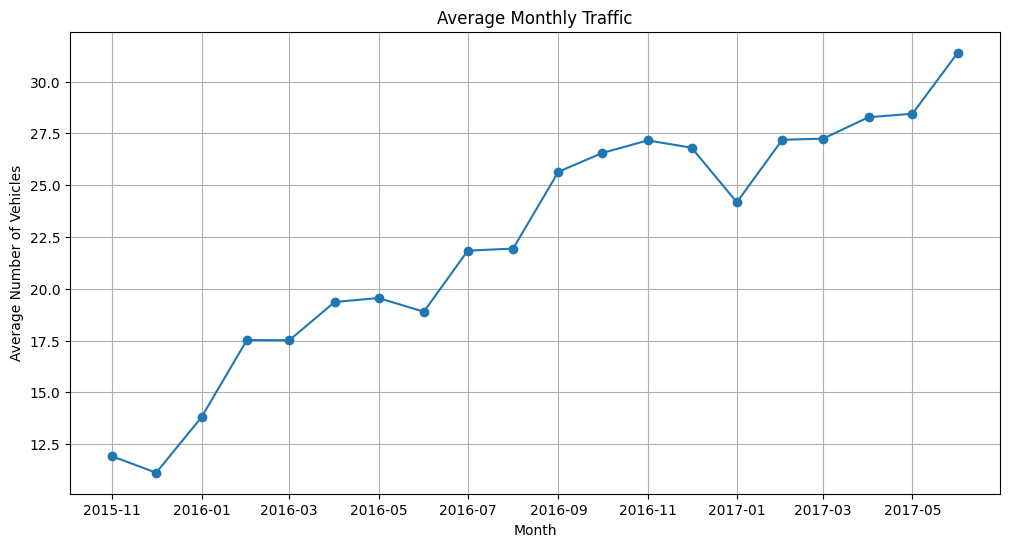

In [15]:
monthly_traffic = df.groupby(df["DateTime"].dt.to_period("M"))["Vehicles"].mean()
monthly_traffic.index = monthly_traffic.index.to_timestamp()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_traffic.index, monthly_traffic.values, marker='o')

plt.title("Average Monthly Traffic")
plt.xlabel("Month")
plt.ylabel("Average Number of Vehicles")
plt.grid(True)

plt.show()

## OBSERVATION:

# Is the traffic increasing over time?

YES,traffic is increasing over time. in november 2015 it was 12.5 and in may.2017 it was 30.

# Are there sudden drops or spikes?

There is only one sudden drop in jaunary 2017
# Does Junction 4 affect the trend?
Yes becausse the data given for junction 4 is started from january 2017 and there is sudden drop in jaunaery 2017 that means by adding one junction the traffic  drops
# Is the trend steady or fluctuating?
It is fluctuating.


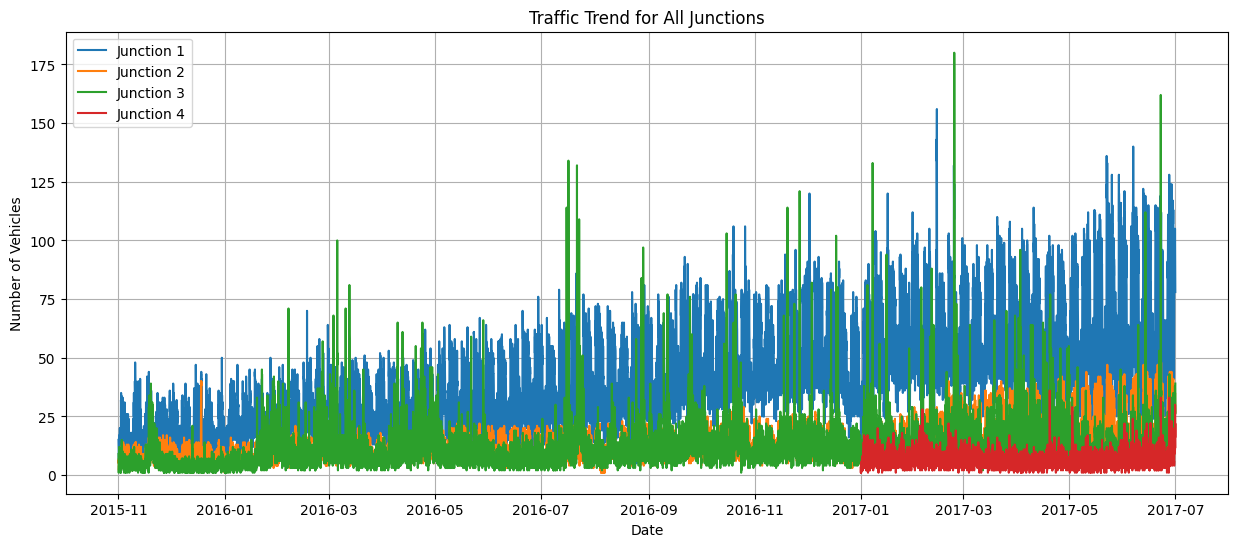

In [16]:
#Traffic Trend for All Junctions
plt.figure(figsize=(15,6))

for junction in sorted(df["Junction"].unique()):
    junction_data = df[df["Junction"] == junction]
    plt.plot(junction_data["DateTime"],
             junction_data["Vehicles"],
             label=f"Junction {junction}")

plt.title("Traffic Trend for All Junctions")
plt.xlabel("Date")
plt.ylabel("Number of Vehicles")
plt.legend()
plt.grid(True)

plt.savefig("static/graphs/traffic_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

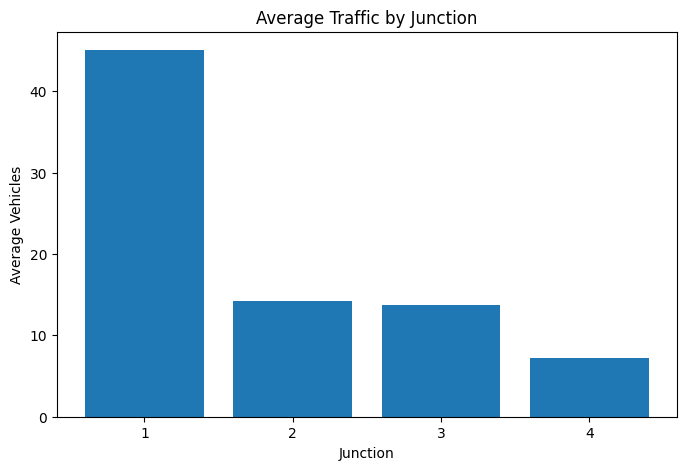

In [17]:
#Average Traffic by Junction
avg_traffic = df.groupby("Junction")["Vehicles"].mean()

plt.figure(figsize=(8,5))

plt.bar(avg_traffic.index.astype(str),
        avg_traffic.values)

plt.title("Average Traffic by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Vehicles")

plt.savefig("static/graphs/junction_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

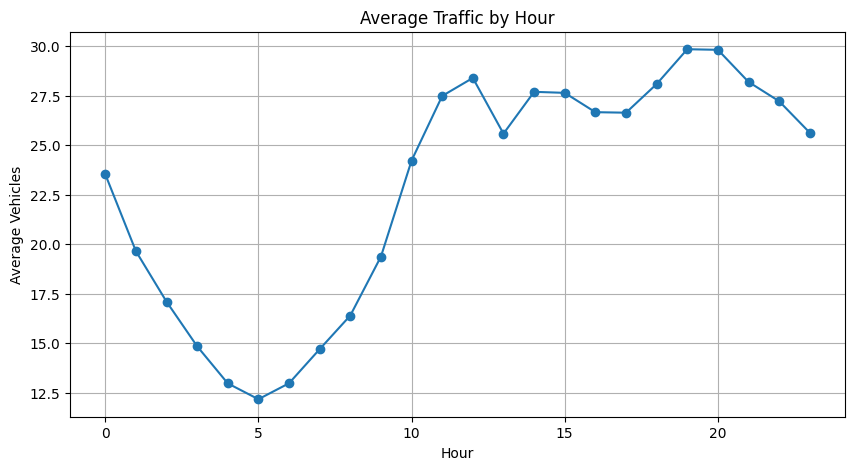

In [18]:
#Average Traffic by Hour
hourly = df.groupby("Hour")["Vehicles"].mean()

plt.figure(figsize=(10,5))

plt.plot(hourly.index,
         hourly.values,
         marker="o")

plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Vehicles")
plt.grid(True)

plt.savefig("static/graphs/hourly_traffic.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

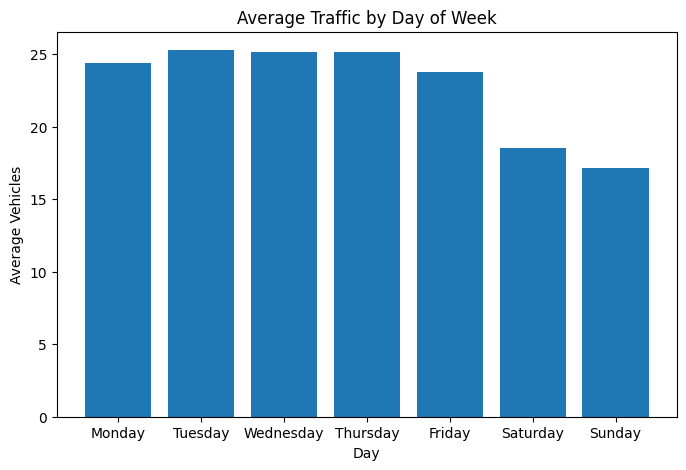

In [19]:
#Average Traffic by Day of Week
days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly = df.groupby("DayOfWeek")["Vehicles"].mean()

plt.figure(figsize=(8,5))

plt.bar(days,
        weekly.values)

plt.title("Average Traffic by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Vehicles")

plt.savefig("static/graphs/weekly_traffic.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

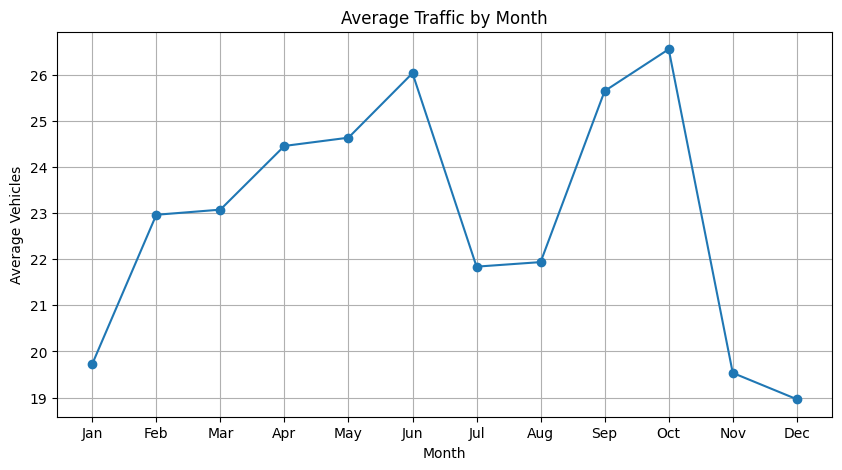

In [20]:
#Average Traffic by Month
months = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

monthly = df.groupby("Month")["Vehicles"].mean()

plt.figure(figsize=(10,5))

plt.plot(monthly.index,
         monthly.values,
         marker="o")

plt.xticks(monthly.index,
           months[:len(monthly.index)])

plt.title("Average Traffic by Month")
plt.xlabel("Month")
plt.ylabel("Average Vehicles")
plt.grid(True)

plt.savefig("static/graphs/monthly_traffic.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

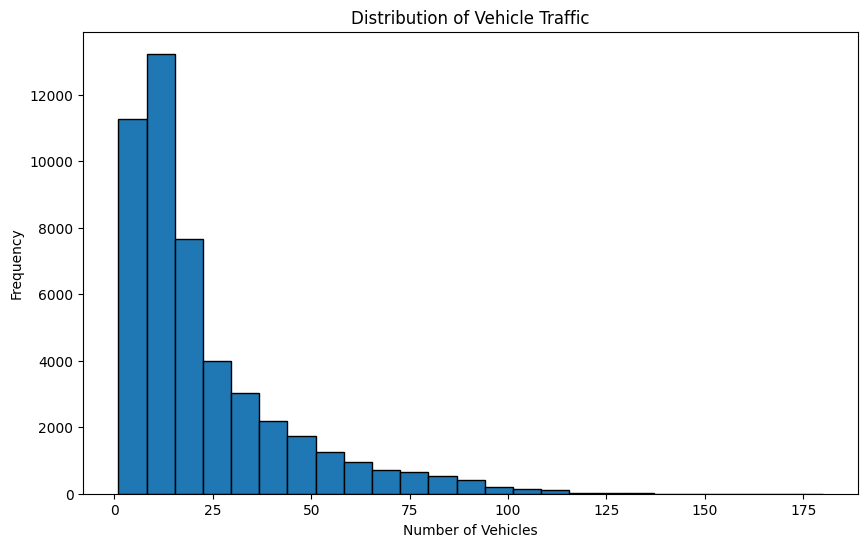

In [21]:
#Distribution of Vehicles
plt.figure(figsize=(10,6))

plt.hist(df["Vehicles"],
         bins=25,
         edgecolor="black")

plt.title("Distribution of Vehicle Traffic")
plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")

plt.savefig("static/graphs/distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

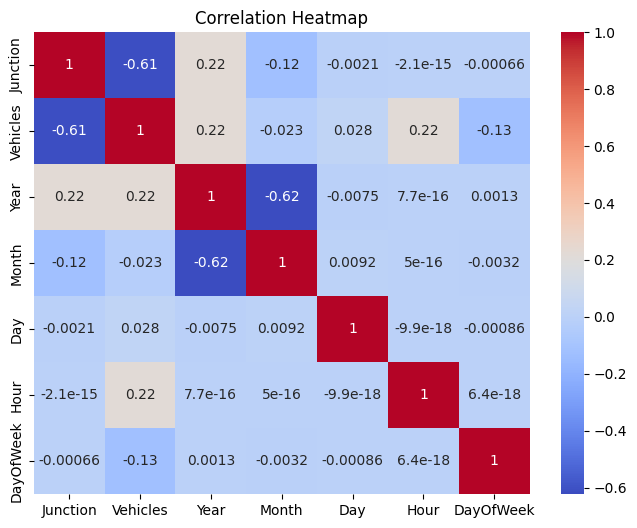

In [22]:
#Correlation Heatmap
import seaborn as sns

corr = df[
    [
        "Junction",
        "Vehicles",
        "Year",
        "Month",
        "Day",
        "Hour",
        "DayOfWeek"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("static/graphs/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [23]:
"""
#Feature Importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.savefig("static/graphs/feature_importance.png",
            dpi=300,
            bbox_inches="tight")
            
"""

plt.show()

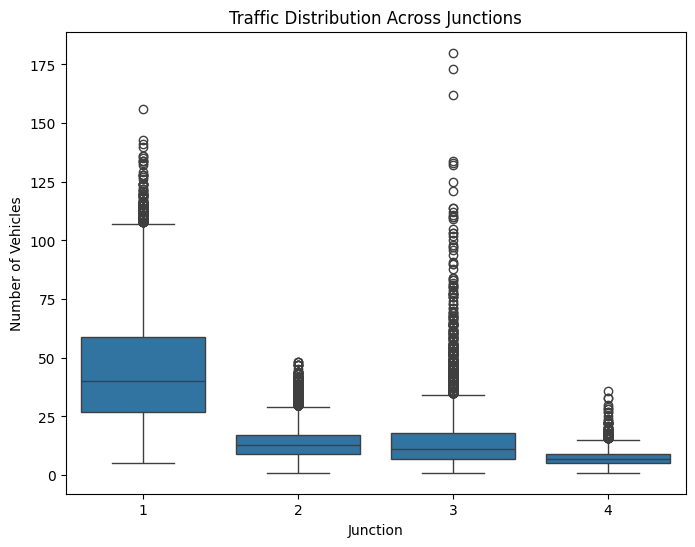

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(x="Junction", y="Vehicles", data=df)

plt.title("Traffic Distribution Across Junctions")
plt.xlabel("Junction")
plt.ylabel("Number of Vehicles")

plt.show()

## OBSERVATION:
# Which junction has the highest median traffic?
Junction 1 has the highest median traffic which is 45.
# Which junction has the largest variation?
Junction 1 has the largest variation.
# Which junction has the most outliers?
Junction 3 has the most outliers.

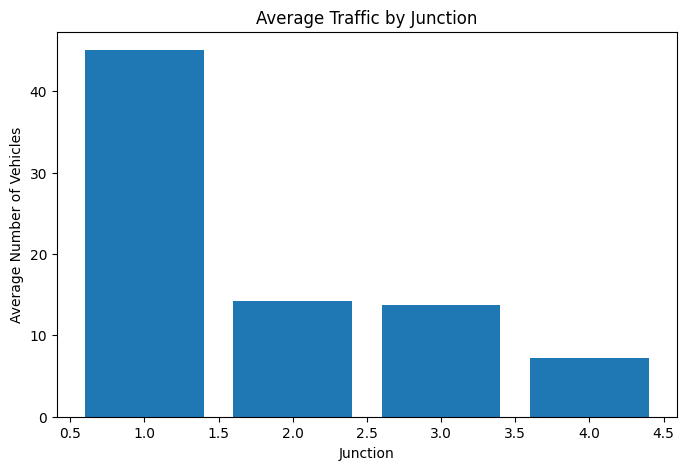

In [25]:
avg_traffic = df.groupby("Junction")["Vehicles"].mean()

plt.figure(figsize=(8,5))

plt.bar(avg_traffic.index, avg_traffic.values)

plt.title("Average Traffic by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Number of Vehicles")

plt.show()

In [26]:
hourly_traffic = df.groupby("Hour")["Vehicles"].mean()
print(hourly_traffic)

Hour
0     23.540648
1     19.654863
2     17.102743
3     14.847382
4     12.973067
5     12.173566
6     12.980050
7     14.703242
8     16.402993
9     19.379551
10    24.229925
11    27.495262
12    28.403990
13    25.588529
14    27.702743
15    27.650374
16    26.674314
17    26.648379
18    28.095262
19    29.854863
20    29.824938
21    28.202993
22    27.226933
23    25.635411
Name: Vehicles, dtype: float64


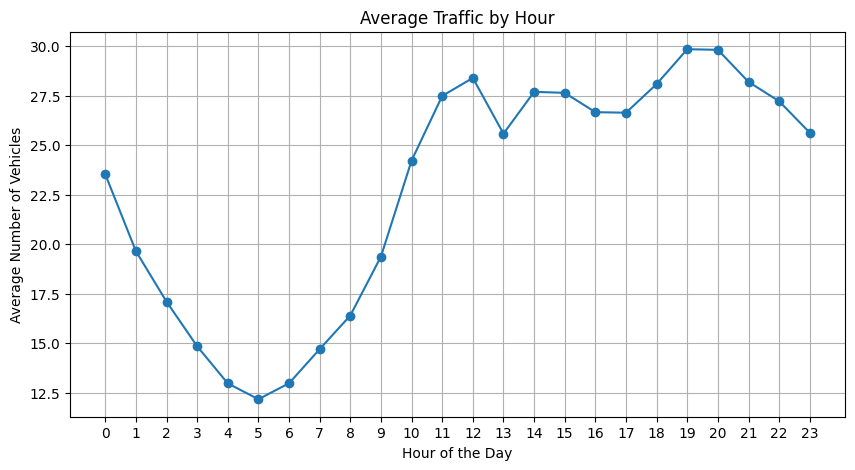

In [27]:
plt.figure(figsize=(10,5))

plt.plot(hourly_traffic.index,
         hourly_traffic.values,
         marker='o')

plt.title("Average Traffic by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Number of Vehicles")

plt.xticks(range(24))
plt.grid(True)

plt.show()

## OBSERVATION :

# Which hour has the highest average traffic?
19 AND 20 hour has the highest avg traffic.
# 2. Is there a morning rush?(7 am to 10 am)
yes there is a morning rush in between 7 am and 10 am ,it is always increasing.
# Is there an evening rush?(5 pm to 8 pm)
yes there is evening rush in between 5 pm to 8 pm,it is increasing.
# What happens at night?(12 am to 5 am)
Traffic decreases steadily after midnight and reaches its lowest level around 5 AM. This indicates minimal vehicle movement during late-night and early-morning hours

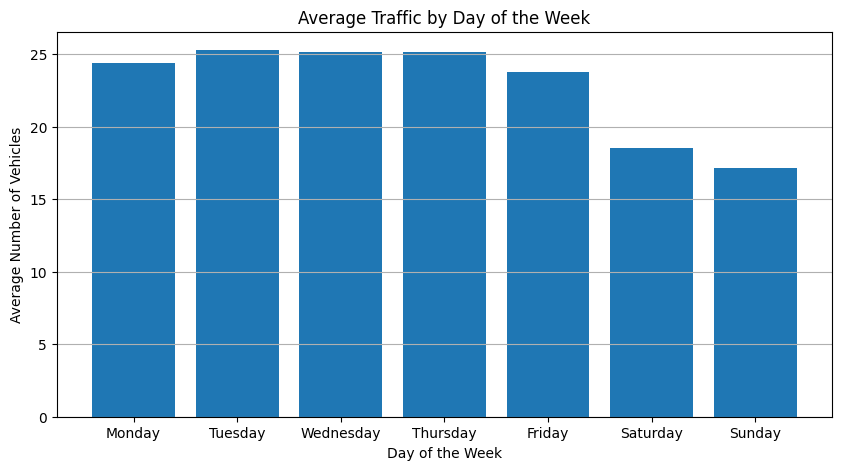

In [28]:
daywise_traffic = df.groupby("DayOfWeek")["Vehicles"].mean()
day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(day_names, daywise_traffic.values)

plt.title("Average Traffic by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Number of Vehicles")

plt.grid(axis='y')

plt.show()

## OBSERVATION :
# Which day has the highest average traffic?
TUESDAY ,WEDNESDAY AND THURSDAY are the busiest days of the week.the average traffic on these days are about 25 . 
# Which day has the lowest traffic?
SUNDAY has the lowest traffic in the whole week the average traffic is something around 17.
# Compare weekdays vs weekends.
weekdays are the busiest days compare to weekends.
# Is there any surprising pattern?
no there is np significant surprising pattern.but yes the monday is not as busy as all other working days.

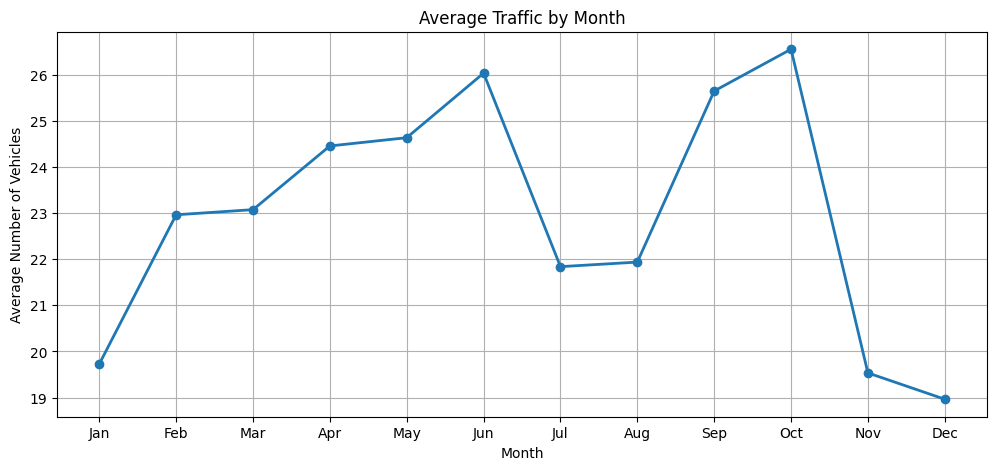

In [29]:
monthly_traffic = df.groupby("Month")["Vehicles"].mean()
month_names = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    month_names,
    monthly_traffic.values,
    marker='o',
    linewidth=2
)

plt.title("Average Traffic by Month")
plt.xlabel("Month")
plt.ylabel("Average Number of Vehicles")

plt.grid(True)

plt.show()

## OBSERVATION :
# Which month has the highest average traffic?
The october month has the highest average traffic(approximately 28 vehicles).
# Which month has the lowest traffic?
The december month has the lowest average traffic (approximately 19 vehicles).
# Is there any seasonal trend?
january to july is contiounsly increasing and after jun we will see the sudden deacrease in the traffic then july and auigust has the constant traffic and after that we will see the sudden increase in the september month and after october it is decresing till december.
# Any unusual spikes?
Yes we can see sudden increasing from august to september and sudden deacreasing from june to july and october to november.

In [30]:
df["Month"].value_counts().sort_index()

Month
1     5208
2     4776
3     5208
4     5040
5     5208
6     5040
7     2232
8     2232
9     2160
10    2232
11    4320
12    4464
Name: count, dtype: int64

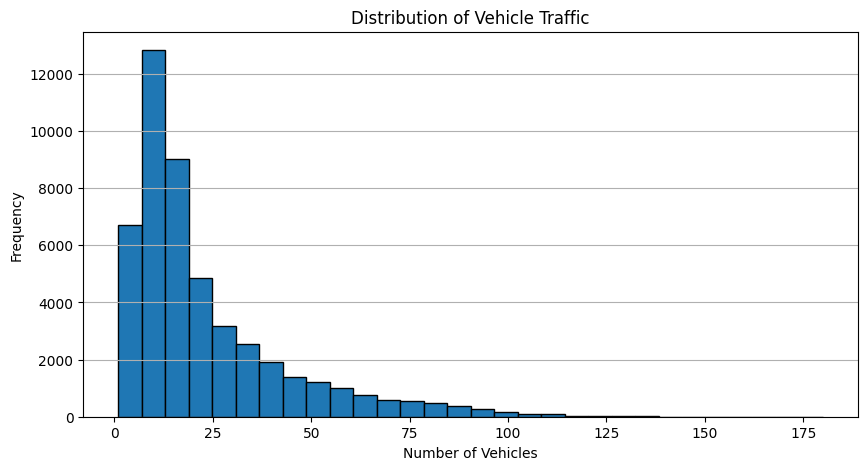

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["Vehicles"], bins=30, edgecolor="black")

plt.title("Distribution of Vehicle Traffic")
plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")

plt.grid(axis="y")

plt.show()

## OBSERVATION :
# Is the distribution normal?
No it is not the normal distribution.
# Is it right-skewed?
yes it is right skewed.
# Is it left-skewed?
no it is not left skewed.
# Any extreme values?
A few observations have very high vehicle counts (above approximately 120 vehicles). These rare observations may represent unusual traffic spikes or peak congestion periods

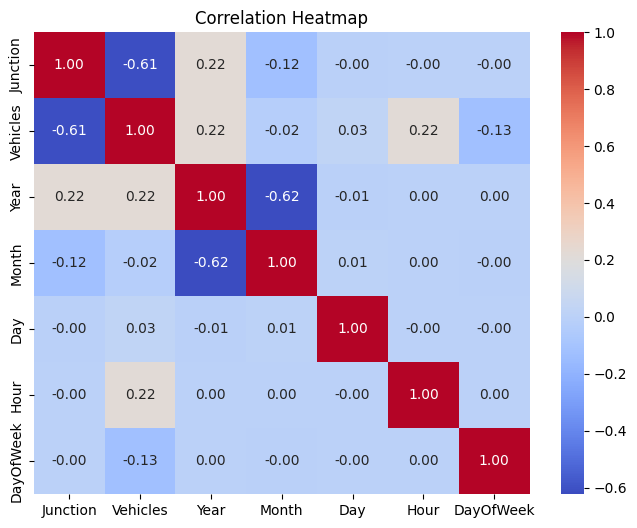

In [32]:
corr_df = df[["Junction","Vehicles","Year","Month","Day","Hour","DayOfWeek"]]
corr_matrix = corr_df.corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## OBSERVATION :

# CORRELATION OF JUNCTION AND TRAFFIC :
Junction has a moderately strong negative correlation (-0.61) with vehicle traffic. This indicates that traffic volume differs across junctions. As the junction number increases, the average traffic tends to decrease in this dataset.

# CORRELATION OF HOUR AND TRAFFIC :
Hour has a weak positive correlation (0.22), indicating that traffic varies with the time of day. Although the linear relationship is weak, the hourly trend analysis showed clear morning and evening traffic peaks.

# CORRELATION OF DAY AND TRAFFIC :
Day has almost no correlation with traffic (0.03), suggesting that the day of the month does not significantly influence traffic volume.

# CORRELATION OF MONTH AND TRAFFIC :
Month shows almost no linear correlation (-0.02), indicating that monthly changes alone do not strongly affect traffic in this dataset.

# CORRELATION OF DAYOFWEEK AND TRAFFIC :
DayOfWeek has a weak negative correlation (-0.13), suggesting a slight variation in traffic across different days of the week. However, the relationship is not strong.

In [33]:
train_data = df[df["DateTime"] < "2017-01-01"]

valid_data = df[df["DateTime"] >= "2017-01-01"]

X_train = train_data[["Junction", "Year", "Month", "Day", "Hour", "DayOfWeek"]]

y_train = train_data["Vehicles"]

In [34]:
X_train = train_data[["Junction", "Year", "Month", "Day", "Hour", "DayOfWeek"]]

y_train = train_data["Vehicles"]

In [35]:
X_valid = valid_data[["Junction", "Year", "Month", "Day", "Hour", "DayOfWeek"]]

y_valid = valid_data["Vehicles"]

In [36]:
print("Training Data:", train_data.shape)
print("Validation Data:", valid_data.shape)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

Training Data: (30744, 9)
Validation Data: (17376, 9)
X_train: (30744, 6)
y_train: (30744,)
X_valid: (17376, 6)
y_valid: (17376,)


In [37]:
print(train_data.shape)
print(valid_data.shape)

(30744, 9)
(17376, 9)


In [38]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [39]:
y_pred = model.predict(X_valid)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_valid, y_pred)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

r2 = r2_score(y_valid, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 14.5152923572744
RMSE : 20.558553242058103
R² Score : 0.3694097535879489


## OBSERVATION 
# MAE (Mean Absolute Error)

It tells us the average difference between the actual traffic and the predicted traffic.

# RMSE (Root Mean Squared Error)

RMSE also measures prediction error but gives more penalty to large errors.

# R² Score

This is the most common interview metric.

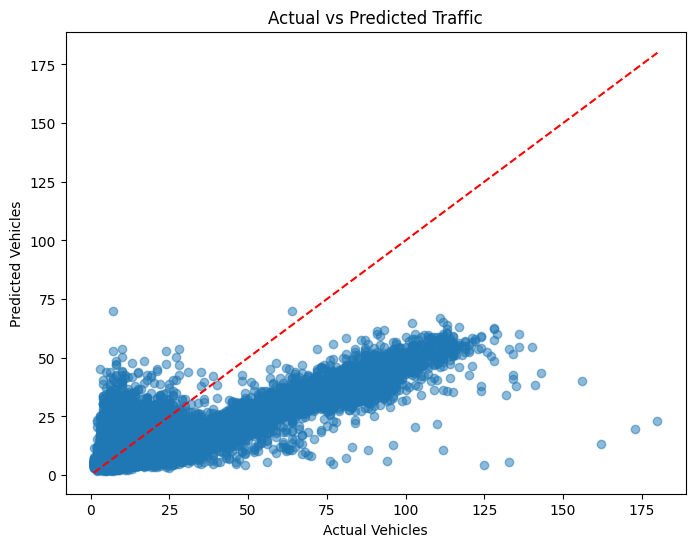

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_valid, y_pred, alpha=0.5)

plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         color='red',
         linestyle='--')

plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")
plt.title("Actual vs Predicted Traffic")

plt.show()

     Feature  Importance
0   Junction    0.513887
4       Hour    0.162556
2      Month    0.129975
5  DayOfWeek    0.079545
1       Year    0.066763
3        Day    0.047274


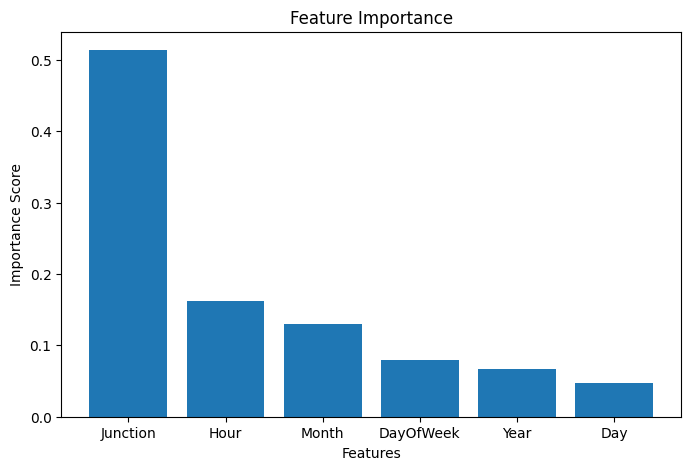

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(8,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

In [42]:
df["IsWeekend"] = df["DayOfWeek"].apply(lambda x: 1 if x >= 5 else 0)
df["Quarter"] = df["DateTime"].dt.quarter
df["WeekOfYear"] = df["DateTime"].dt.isocalendar().week.astype(int)
df["DayOfYear"] = df["DateTime"].dt.dayofyear
df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek,IsWeekend,Quarter,WeekOfYear,DayOfYear
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6,1,4,44,305
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6,1,4,44,305
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6,1,4,44,305
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6,1,4,44,305
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6,1,4,44,305


In [43]:
features = [
    "Junction",
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "Quarter",
    "WeekOfYear",
    "DayOfYear"
]

In [44]:
train_data = df[df["DateTime"] < "2017-01-01"]
valid_data = df[df["DateTime"] >= "2017-01-01"]
X_train = train_data[features]
y_train = train_data["Vehicles"]

X_valid = valid_data[features]
y_valid = valid_data["Vehicles"]

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_valid)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 14.518857619705342
RMSE : 20.553522520499754
R² Score : 0.36971832936879945


In [45]:
import pandas as pd

test_df = pd.read_csv("C:/Users/ACER/Downloads/Project9_smart-city-traffic-patterns (1)/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns/smart-city-traffic-patterns/TESTING_TRAFFIC.csv")

In [46]:
test_df["DateTime"] = pd.to_datetime(test_df["DateTime"])
test_df["Year"] = test_df["DateTime"].dt.year
test_df["Month"] = test_df["DateTime"].dt.month
test_df["Day"] = test_df["DateTime"].dt.day
test_df["Hour"] = test_df["DateTime"].dt.hour
test_df["DayOfWeek"] = test_df["DateTime"].dt.dayofweek
test_df["IsWeekend"] = test_df["DayOfWeek"].apply(lambda x: 1 if x >= 5 else 0)

test_df["Quarter"] = test_df["DateTime"].dt.quarter

test_df["WeekOfYear"] = test_df["DateTime"].dt.isocalendar().week.astype(int)

test_df["DayOfYear"] = test_df["DateTime"].dt.dayofyear

In [47]:
features = [
    "Junction",
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "Quarter",
    "WeekOfYear",
    "DayOfYear"
]

X_test = test_df[features]

test_predictions = model.predict(X_test)

test_df["Predicted_Vehicles"] = test_predictions

In [48]:
print(len(X_train.columns))
print(len(model.feature_importances_))

10
10


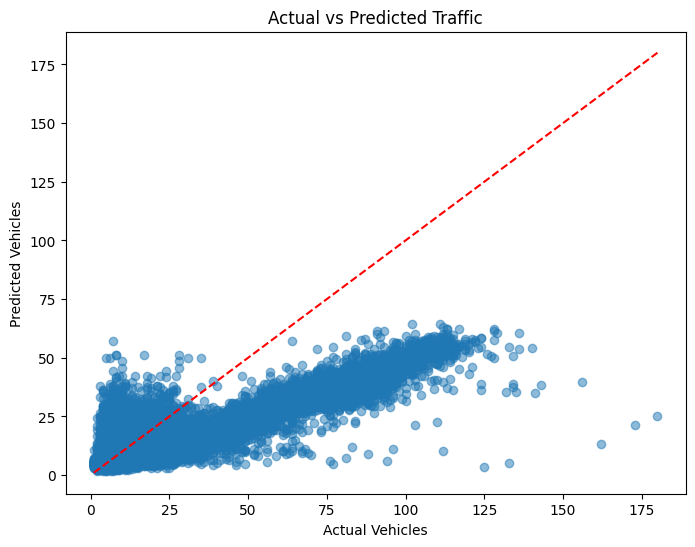

In [49]:
#Actual vs Predicted
plt.figure(figsize=(8,6))


plt.scatter(y_valid,
            y_pred,
            alpha=0.5)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    "r--"
)

plt.title("Actual vs Predicted Traffic")
plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")

plt.savefig("static/graphs/actual_vs_predicted.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

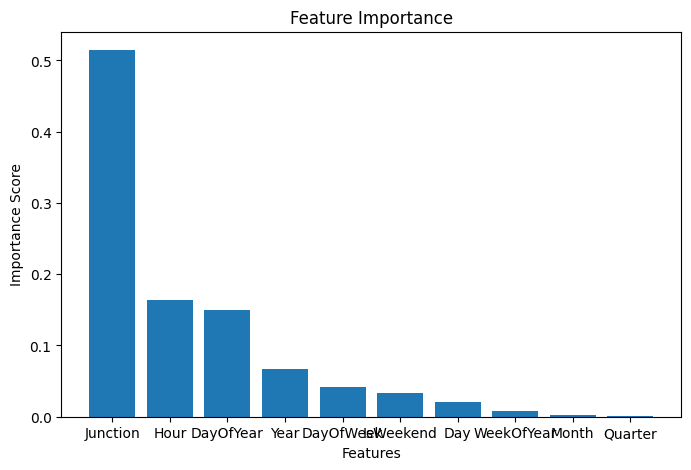

In [50]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.savefig("static/graphs/feature_importance.png",
            dpi=300,
            bbox_inches="tight")


In [51]:
print(test_df.head())

             DateTime  Junction           ID  Year  Month  Day  Hour  \
0 2017-07-01 00:00:00         1  20170701001  2017      7    1     0   
1 2017-07-01 01:00:00         1  20170701011  2017      7    1     1   
2 2017-07-01 02:00:00         1  20170701021  2017      7    1     2   
3 2017-07-01 03:00:00         1  20170701031  2017      7    1     3   
4 2017-07-01 04:00:00         1  20170701041  2017      7    1     4   

   DayOfWeek  IsWeekend  Quarter  WeekOfYear  DayOfYear  Predicted_Vehicles  
0          5          1        3          26        182               34.02  
1          5          1        3          26        182               28.95  
2          5          1        3          26        182               26.23  
3          5          1        3          26        182               22.14  
4          5          1        3          26        182               17.08  


In [52]:
import joblib

joblib.dump(model, "traffic_model.pkl")

['traffic_model.pkl']

In [53]:
import os

print(os.listdir())

['app.py', 'dataset', 'requirements.txt', 'static', 'templates', 'traffic_model.pkl', 'traffic_predictions.csv', 'TRAFIC_ANALYSIS.ipynb']


In [54]:
test_df.to_csv("traffic_predictions.csv", index=False)